In [1]:
%pip install tabulate seaborn umap-learn plotly biopython ipywidgets

Looking in indexes: https://pypi.org/simple, https://pypi.ngc.nvidia.com
     |████████████████████████████████| 88 kB 3.5 MB/s eta 0:00:01
     |████████████████████████████████| 14.8 MB 7.7 MB/s eta 0:00:01
     |████████████████████████████████| 3.1 MB 3.8 MB/s eta 0:00:01
     |████████████████████████████████| 139 kB 10.1 MB/s eta 0:00:01
     |████████████████████████████████| 56 kB 10.8 MB/s ta 0:00:011
     |████████████████████████████████| 313 kB 9.5 MB/s eta 0:00:01
     |████████████████████████████████| 2.3 MB 9.6 MB/s eta 0:00:01
     |████████████████████████████████| 214 kB 3.9 MB/s eta 0:00:01
  Attempting uninstall: comm
    Found existing installation: comm 0.1.2
    Uninstalling comm-0.1.2:
      Successfully uninstalled comm-0.1.2
You should consider upgrading via the '/usr/bin/python -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import torch
import numpy as np

from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
)

In [2]:
SELECTED_SPECIES = ['Sinorhizobium meliloti 1021', 'Bradyrhizobium japonicum USDA 110',
                    'Shigella flexneri 5a str. M90T', 'Burkholderia cenocepacia J2315',
                    'Escherichia coli str K-12 substr. MG1655',
                    'Pseudomonas putida strain KT2440',
                    'Xanthomonas campestris pv. campestrie B100',
                    'Acinetobacter baumannii ATCC 17978',
                    'Klebsiella aerogenes KCTC 2190',
                    'Agrobacterium tumefaciens str C58',]

In [3]:
cds_dataset = pd.read_csv("./data/processed/cds/dataset.csv")
random_dataset = pd.read_csv("./data/processed/random/dataset.csv")
all_promoters_df = pd.read_csv("./data/processed/all_promoters.csv")
species_class_df = pd.read_csv("./data/processed/species_classification.csv", sep=";")

/tmp/ipykernel_156/2087441572.py:3: DtypeWarning: Columns (12) have mixed types. Specify dtype option on import or set low_memory=False.
  all_promoters_df = pd.read_csv("./data/processed/all_promoters.csv")


In [4]:
for dataset in [cds_dataset, random_dataset]:
    dataset['id'] = dataset['id'].str.replace('id=', '')

all_promoters_df = all_promoters_df[all_promoters_df['SpeciesName'].isin(SELECTED_SPECIES)]
promoters_filtered_df = cds_dataset[cds_dataset['label'] == 1]

# define id as a string for both dataframes
all_promoters_df['id'] = all_promoters_df['id'].astype(str)
promoters_filtered_df['id'] = promoters_filtered_df['id'].astype(str)


/tmp/ipykernel_156/1381403473.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  promoters_filtered_df['id'] = promoters_filtered_df['id'].astype(str)


In [5]:
filtered_promoters_ppd_df = pd.merge(all_promoters_df, promoters_filtered_df, on=['id', 'SpeciesName'], how='inner')

In [6]:
filtered_promoters_ppd_df['Strand'].value_counts()

+    33625
-    32022
Name: Strand, dtype: int64

In [7]:
from Bio import SeqIO

genoma_path = "./data/genomas/Xcampestris_GCF_000070605.1_ASM7060v1_genomic.fna"
SELECTED_GENOMA_SPECIE = 'Xanthomonas campestris pv. campestrie B100'

In [8]:
def get_genome_sequences(genoma_path, specie):
    genome_seqs = []
    genome_reverse_seqs = None

    with open(genoma_path, "r") as fna_file:
        for record in SeqIO.parse(fna_file, "fasta"):
            genome_seq = record.seq.lower()
            genome_reverse_seq = record.seq.reverse_complement().lower()[::-1]
            genome_seqs.append(genome_seq)
            genome_reverse_seqs = genome_reverse_seq

    return genome_seqs, genome_reverse_seqs

In [9]:
selected_genome_seqs, selected_genome_reverse_seqs = get_genome_sequences(genoma_path, SELECTED_GENOMA_SPECIE)

In [10]:
genome_seq = selected_genome_seqs[0]
genome_reverse_seq = selected_genome_reverse_seqs

In [11]:
genome_seq

Seq('atggatgcttggccccgctgtctggaacgtctcgaagctgaattcccgcccgaa...ttg')

In [12]:
genome_reverse_seq

Seq('tacctacgaaccggggcgacagaccttgcagagcttcgacttaagggcgggctt...aac')

In [13]:
specie_promoters = filtered_promoters_ppd_df[filtered_promoters_ppd_df['SpeciesName'] == SELECTED_GENOMA_SPECIE]

In [14]:
specie_promoters

,id,Type,PromoterName,SpeciesName,GeneName,GeneStart,GeneEnd,GeneProduct,TSSPosition,Strand,Locus_tag,Sequence_x,Category,GCPercentage,Sequence_y,label
60418,3067,chr,NaN,Xanthomonas campestris pv. campestrie B100,rpmH,NaN,NaN,50S ribosomal protein L34,5078791.0,-,xcc-b100_4468,cttgcggtaaagccagcagggagttgacccggccccaacagctcct...,NaN,54.3210,cttgcggtaaagccagcagggagttgacccggccccaacagctcct...,1
60419,3066,chr,NaN,Xanthomonas campestris pv. campestrie B100,xcc-b100_4466,NaN,NaN,inner membrane insertion protein,5077964.0,+,xcc-b100_4466,aggcaccgcggcagggctgccggcttgcggaatcgcctgtgccgac...,NaN,75.3086,aggcaccgcggcagggctgccggcttgcggaatcgcctgtgccgac...,1
60420,3065,chr,NaN,Xanthomonas campestris pv. campestrie B100,xcc-b100_4464,NaN,NaN,tRNA modification GTPase TrmE,5073518.0,+,xcc-b100_4464,gatgcccagcgcggcggcgatctgtacagactgcgggccggacagc...,NaN,67.9012,gatgcccagcgcggcggcgatctgtacagactgcgggccggacagc...,1
60421,3064,chr,NaN,Xanthomonas campestris pv. campestrie B100,xcc-b100_4463,NaN,NaN,TonB-dependent outer membrane receptor precursor,5068969.0,+,xcc-b100_4463,gatctcgttaaaagttcccggaagatgacatctctgtaaatcctgg...,NaN,43.2099,gatctcgttaaaagttcccggaagatgacatctctgtaaatcctgg...,1
60422,3063,chr,NaN,Xanthomonas campestris pv. campestrie B100,xcc-b100_4463,NaN,NaN,TonB-dependent outer membrane receptor precursor,5068810.0,+,xcc-b100_4463,accacctcgctgaggtcgaaaggccagcgcgcactggcatgcctag...,NaN,61.7284,accacctcgctgaggtcgaaaggccagcgcgcactggcatgcctag...,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
63376,5,chr,NaN,Xanthomonas campestris pv. campestrie B100,xcc-b100_0123,141218.0,137877.0,transcriptional regulator,141295.0,-,xcc-b100_0123,gcgcggcgaacagagaccatggtcgaatttcggcaccagtggctgt...,NaN,65.4321,gcgcggcgaacagagaccatggtcgaatttcggcaccagtggctgt...,1
63377,4,chr,NaN,Xanthomonas campestris pv. campestrie B100,xcc-b100_0093,100808.0,101638.0,conserved hypothetical protein,100795.0,+,xcc-b100_0093,tcgccgcaaaggttgcgcccgcttgtgcaccgctcacatgcggctg...,NaN,64.1975,tcgccgcaaaggttgcgcccgcttgtgcaccgctcacatgcggctg...,1
63378,3,chr,NaN,Xanthomonas campestris pv. campestrie B100,xcc-b100_0080,87747.0,88613.0,hypothetical protein,87726.0,+,xcc-b100_0080,tcagacgagcggcagctgcggggctggcacctgtggcgtgcttccg...,NaN,65.4321,tcagacgagcggcagctgcggggctggcacctgtggcgtgcttccg...,1
63379,2,chr,NaN,Xanthomonas campestris pv. campestrie B100,xcc-b100_0078,86817.0,86629.0,conserved hypothetical protein,86843.0,-,xcc-b100_0078,tgtgtgcatcgcagcaacagacgcacaccatgctcacaccggccca...,NaN,58.0247,tgtgtgcatcgcagcaacagacgcacaccatgctcacaccggccca...,1


In [15]:
specie_promoters_pos = specie_promoters[specie_promoters['Strand'] == '+']
specie_promoters_neg = specie_promoters[specie_promoters['Strand'] == '-']

In [16]:
# count by positive and negative strand
specie_promoters['Strand'].value_counts()

+    1559
-    1404
Name: Strand, dtype: int64

In [17]:
# check if positive strands are in the genome

for idx, row in specie_promoters_pos.iterrows():
    # groundtruth data
    promoter_seq = row['Sequence_x']

    # check if sequence are stracted based on TSS rule
    promoter_tss = int(row['TSSPosition'])
    lower_bound = promoter_tss - 60 - 1
    upper_bound = promoter_tss + 20
    #print(lower_bound, upper_bound)
    promoter_seq_from_genoma = genome_seq[lower_bound:upper_bound]

    if promoter_seq != promoter_seq_from_genoma:
        print(f"+ Promoter {row['id']} is not equal to the genome sequence")
        #print(lower_bound, upper_bound)
        print(f"Promoter seq: {promoter_seq}")
        print(f"Genoma seq  : {promoter_seq_from_genoma}")
        break


for idx, row in specie_promoters_neg.iterrows():
   # groundtruth data
   promoter_seq = row['Sequence_x']
   # check if sequence are stracted based on TSS rule
   promoter_tss = int(row['TSSPosition'])
   lower_bound = promoter_tss - 20 - 1
   upper_bound = promoter_tss + 60
   promoter_seq_from_genoma = genome_reverse_seq[lower_bound:upper_bound][::-1]
   if promoter_seq != promoter_seq_from_genoma:
       print(f"- Promoter {row['id']} is not equal to the genome sequence")
       print(lower_bound, upper_bound)
       print(f"Promoter seq: {promoter_seq}")
       print(f"Genoma seq:   {promoter_seq_from_genoma}")
       break

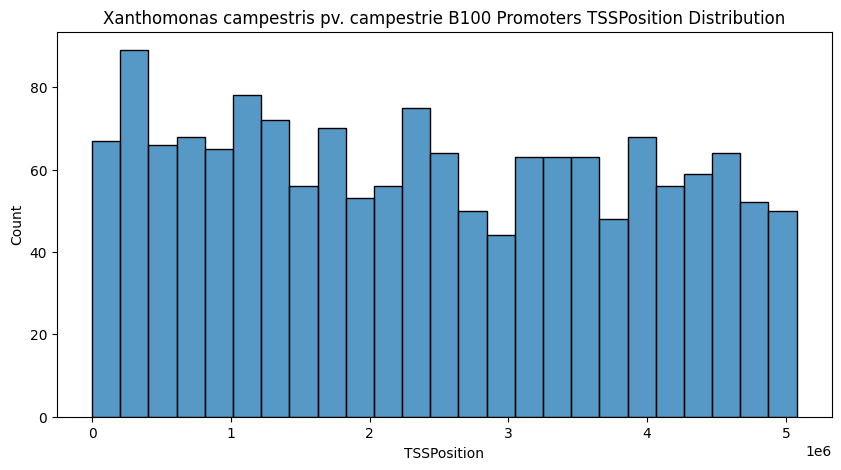

In [18]:
# create plot for TSSPosition distribution (histogram ) for positive strands

plt.figure(figsize=(10, 5))
sns.histplot(specie_promoters_pos['TSSPosition'], bins=25)
plt.title(f"{SELECTED_GENOMA_SPECIE} Promoters TSSPosition Distribution")
plt.xlabel("TSSPosition")
plt.ylabel("Count")
plt.show()


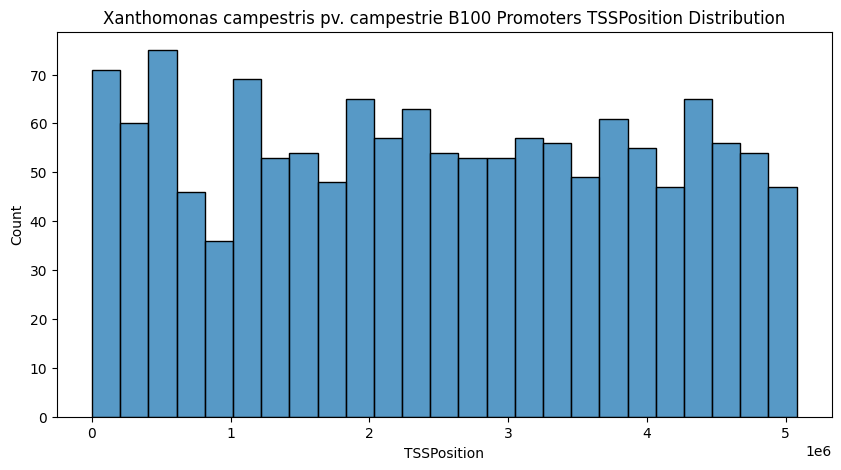

In [19]:
# create plot for TSSPosition distribution (histogram ) for positive strands

plt.figure(figsize=(10, 5))
sns.histplot(specie_promoters_neg['TSSPosition'], bins=25)
plt.title(f"{SELECTED_GENOMA_SPECIE} Promoters TSSPosition Distribution")
plt.xlabel("TSSPosition")
plt.ylabel("Count")
plt.show()


In [20]:
cds_dataset_train, cds_dataset_test = train_test_split(cds_dataset, test_size=0.2, random_state=42)

In [21]:
promoters_test_cds_df = cds_dataset_test[cds_dataset_test['label'] == 1]
non_promoters_test_cds_df = cds_dataset_test[cds_dataset_test['label'] == 0]
promoters_test_cds_df = pd.merge(promoters_test_cds_df, all_promoters_df, on=['id', 'SpeciesName'], how='inner')
non_promoters_test_cds_df = pd.merge(non_promoters_test_cds_df, all_promoters_df, on=['id', 'SpeciesName'], how='inner')

promoters_train_cds_df = cds_dataset_train[cds_dataset_train['label'] == 1]
promoters_train_cds_df = pd.merge(promoters_train_cds_df, all_promoters_df, on=['id', 'SpeciesName'], how='inner')


In [23]:
specie_promoters_pos['TSSPosition_lower_bound'] = specie_promoters_pos['TSSPosition'] - 60 - 1
specie_promoters_pos['TSSPosition_upper_bound'] = specie_promoters_pos['TSSPosition'] + 20

/tmp/ipykernel_156/1283526841.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  specie_promoters_pos['TSSPosition_lower_bound'] = specie_promoters_pos['TSSPosition'] - 60 - 1
/tmp/ipykernel_156/1283526841.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  specie_promoters_pos['TSSPosition_upper_bound'] = specie_promoters_pos['TSSPosition'] + 20


In [26]:
pos_promoters_tss_positions = specie_promoters_pos[['TSSPosition_lower_bound', 'TSSPosition_upper_bound']].values

In [27]:
def plot_nucleotide_values_merged(seq1, y_values_1, y_values_2, highlight_range=None, red_highlight_range_list=[], width=35, height=8, title=""):
    if len(seq1) != len(y_values_1) != len(y_values_2):
        raise ValueError("The length of the sequences must be the same")

    fig, axs = plt.subplots(2, 1, figsize=(width, height))

    fig.suptitle(title, fontsize=14)

    x_positions_1 = range(len(seq1))
    #set title for the first sequence
    axs[0].set_title("CDS")
    axs[0].set_xticks([])
    axs[0].plot(x_positions_1, y_values_1, linestyle='-', color='blue')
    axs[0].set_ylim(0, 1)
    axs[0].set_ylabel("Probability")
    axs[0].margins(0)

    start = None
    end = None
    if highlight_range:
        start, end = highlight_range
        axs[0].axvspan(start, end, color='green', alpha=0.3)

    if start:
        tss_zero = start + 60
        ticks = np.arange(0, len(seq1), 1000)
        new_ticks = [tick - tss_zero for tick in ticks]
        plt.xticks(ticks, [f'{int(tick)}' for tick in new_ticks])
        plt.xlabel("Position relative to TSS")

    if red_highlight_range_list:
        for start, end in red_highlight_range_list:
            axs[0].axvspan(start, end, color='red', alpha=0.3)

    axs[1].set_title("SRS")
    axs[1].plot(x_positions_1, y_values_2, linestyle='-', color='blue')
    axs[1].set_ylim(0, 1)
    axs[1].set_ylabel("Probability")
    axs[1].set_xlabel("Position relative to TSS")
    axs[1].margins(0)

    if highlight_range:
        start, end = highlight_range
        axs[1].axvspan(start, end, color='green', alpha=0.3)

    if red_highlight_range_list:
        for start, end in red_highlight_range_list:
            axs[1].axvspan(start, end, color='red', alpha=0.3)

    plt.tight_layout()

    filename = f"{title}.pdf"
    plt.savefig(filename)
    plt.show()

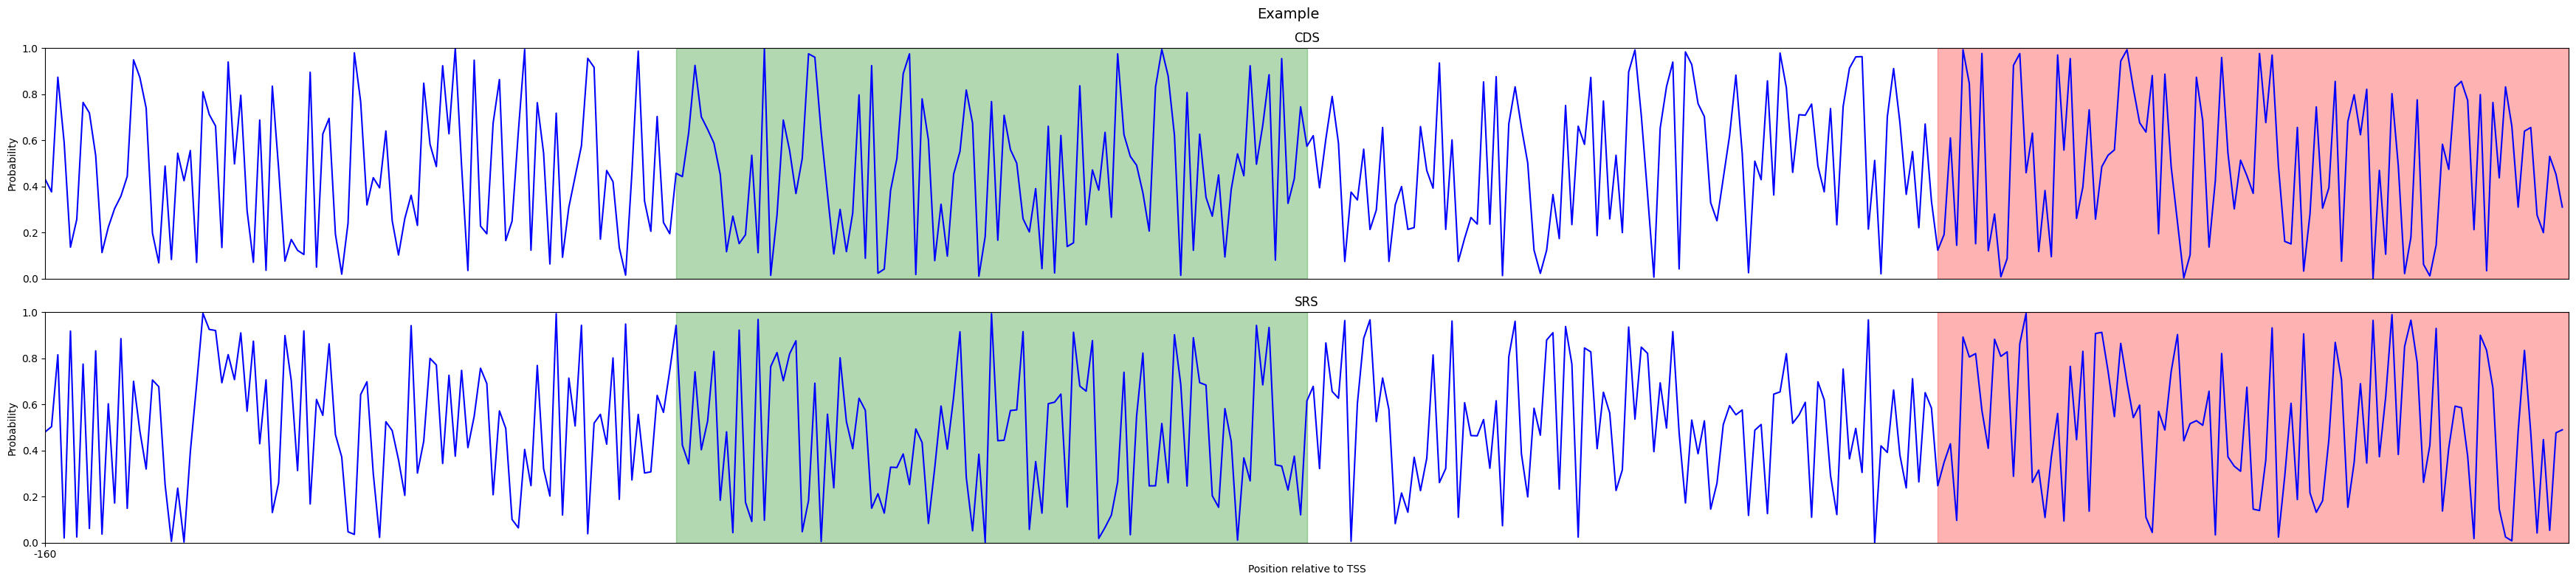

In [29]:
# example
seq1 = "ATCG" * 100
seq2 = "GCTA" * 100
values_1 = np.random.rand(len(seq1))
values_2 = np.random.rand(len(seq2))

plot_nucleotide_values_merged(seq1, values_1, values_2, highlight_range=(100, 200), red_highlight_range_list=[(300, 400)], title="Example")


In [30]:
from scripts.utils.bert import return_kmer

In [31]:
model_cds_path = "./scripts/models/cds-BERTOptimizer_09d03_00003"
model_random_path = "./scripts/models/random-BERTOptimizer_12395_00002"

In [32]:
def load_model(path):
    DEVICE = "cuda:0" if torch.cuda.is_available() else "cpu"
    
    tokenizer = AutoTokenizer.from_pretrained(
        path,
        padding_side="right",
        use_fast=True,
        trust_remote_code=True
    )

    model = AutoModelForSequenceClassification.from_pretrained(
        path,
        num_labels=2,
        trust_remote_code=True,
        output_hidden_states=True
    )

    model.to(DEVICE)
    return model, tokenizer

In [33]:
model_cds, tokenizer_cds = load_model(model_cds_path)
model_random, tokenizer_random = load_model(model_random_path)

/usr/local/lib/python3.8/dist-packages/huggingface_hub/file_download.py:797: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


configuration_bert.py:   0%|          | 0.00/807 [00:00<?, ?B/s]

A new version of the following files was downloaded from https://huggingface.co/zhihan1996/DNA_bert_3:
- configuration_bert.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.


dnabert_layer.py:   0%|          | 0.00/5.44k [00:00<?, ?B/s]

A new version of the following files was downloaded from https://huggingface.co/zhihan1996/DNA_bert_3:
- dnabert_layer.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.


In [34]:
DNABERT_MAX_LEN = 128

In [35]:
def extract_substrings(sequence, L, stride=1):
    if L > len(sequence):
        raise ValueError("L cant be greater than the sequence length.")
    if L <= 0 or stride <= 0:
        raise ValueError("L and stride must be positive integers.")
    
    substrings = [sequence[i:i+L] for i in range(0, len(sequence) - L + 1, stride)]
    return substrings

In [36]:
class EvalTorchDataset(torch.utils.data.Dataset):
    def __init__(self, input_ids, attention_mask, token_type_ids):
        self.input_ids = input_ids
        self.attention_mask = attention_mask
        self.token_type_ids = token_type_ids

    def __len__(self):
        return len(self.input_ids)

    def __getitem__(self, idx):
        return {
            'input_ids': self.input_ids[idx],
            'attention_mask': self.attention_mask[idx],
            'token_type_ids': self.token_type_ids[idx]
        }

In [37]:
def get_section_dataloader(section, L, model_tokenizer, stride=1):
    section_subsequences = extract_substrings(section, L, stride)
    section_kmers = [return_kmer(str(substring), K=3) for substring in section_subsequences]
    section_kmers = [seq.upper() for seq in section_kmers]
    section_subsequences_encodings = model_tokenizer(
        section_kmers,
        max_length=DNABERT_MAX_LEN,
        padding="longest",
        truncation=True,
        return_tensors="pt",
    )

    section_subsequences_dataset = EvalTorchDataset(section_subsequences_encodings['input_ids'],
                                                section_subsequences_encodings['attention_mask'],
                                                section_subsequences_encodings['token_type_ids'])

    section_subsequences_dataloader = DataLoader(section_subsequences_dataset, batch_size=32, shuffle=False)

    return section_subsequences, section_subsequences_dataloader

In [41]:
TSS = 4691345
lower_bound = TSS - 60 - 1
upper_bound = TSS + 20

genome_seq[lower_bound:upper_bound]

WINDOW = 250
promoter_section_lower_bound = lower_bound - WINDOW
promoter_section_upper_bound = upper_bound + WINDOW
section = genome_seq[promoter_section_lower_bound:promoter_section_upper_bound]
promoter_section = genome_seq[lower_bound:upper_bound]

L = 81
stride = 1

section_subsequences, section_subsequences_dataloader = get_section_dataloader(section, L, tokenizer_cds, stride)

In [42]:
DEVICE = "cuda:0" if torch.cuda.is_available() else "cpu"

def get_data_predictions(model, dataloader):
    model.eval()
    predictions = []
    probabilities = []
    predicted_labels = []

    with torch.no_grad():
        for batch in dataloader:
            input_ids = batch['input_ids'].to(DEVICE)
            attention_mask = batch['attention_mask'].to(DEVICE)
            token_type_ids = batch['token_type_ids'].to(DEVICE)
            outputs = model(input_ids, attention_mask=attention_mask, token_type_ids=token_type_ids)
            logits = outputs.logits
            probability = torch.softmax(logits, dim=1)
            prediction = torch.argmax(probability, dim=1)
            probabilities.append(probability)
            predictions.append(logits)
            predicted_labels.append(prediction)

    return predictions, probabilities, predicted_labels

In [43]:
cds_predictions, cds_probabilities, cds_predicted_labels = get_data_predictions(model_cds, section_subsequences_dataloader)
random_predictions, random_probabilities, random_predicted_labels = get_data_predictions(model_random, section_subsequences_dataloader)

In [44]:
def get_subsequences_predictions_df(section_subsequences, probabilities, predicted_labels):
    pos_probabilities = torch.cat(probabilities).cpu().numpy()[:, 1]

    subseq_predicts_df = pd.DataFrame({
        'subsequence': [str(seq) for seq in section_subsequences],
        'prediction': torch.cat(predicted_labels).cpu().numpy(),
        'probability': pos_probabilities
    })

    return subseq_predicts_df

In [45]:
section_subsequences_predictions_cds = get_subsequences_predictions_df(section_subsequences, cds_probabilities, cds_predicted_labels)

In [46]:
section_subsequences_predictions_cds

,subsequence,prediction,probability
0,ggagaattcatggatccaggtgatgctgggccagggcatcgtgccg...,0,0.105894
1,gagaattcatggatccaggtgatgctgggccagggcatcgtgccgc...,0,0.126875
2,agaattcatggatccaggtgatgctgggccagggcatcgtgccgcg...,0,0.153889
3,gaattcatggatccaggtgatgctgggccagggcatcgtgccgcgg...,0,0.115834
4,aattcatggatccaggtgatgctgggccagggcatcgtgccgcggc...,0,0.090837
...,...,...,...
496,ggcaccacgccagcggcaccggccaccgcgccggcacctacggcag...,1,0.667903
497,gcaccacgccagcggcaccggccaccgcgccggcacctacggcagc...,0,0.179232
498,caccacgccagcggcaccggccaccgcgccggcacctacggcagcc...,0,0.098171
499,accacgccagcggcaccggccaccgcgccggcacctacggcagcca...,0,0.064974


In [47]:
def average_probability_per_nucleotide(df, original_sequence, stride=1):
    original_sequence_length = len(original_sequence)

    nucleotide_probabilities = {i: [] for i in range(original_sequence_length)}

    for idx, row in df.iterrows():
        subsequence = row['subsequence']
        probability = row['probability']

        start_position = idx * stride

        for i, nucleotide in enumerate(subsequence):
            global_index = start_position + i
            if global_index < original_sequence_length:
                nucleotide_probabilities[global_index].append(probability)

    avg_probabilities = {
        'position': [],
        'nucleotide': [],
        'average_probability': []
    }

    for i in range(original_sequence_length):
        avg_probabilities['position'].append(i)
        avg_probabilities['nucleotide'].append(original_sequence[i])
        avg_probabilities['average_probability'].append(
            np.mean(nucleotide_probabilities[i]) if nucleotide_probabilities[i] else 0
        )

    result_df = pd.DataFrame(avg_probabilities)
    return result_df

In [48]:
def plot_section(section, section_predictions_cds, section_prediction_random, promoter_range, other_promoter_ranges=[], width=35, height=4, title=""):
    result_cds_df = average_probability_per_nucleotide(section_predictions_cds, section.upper())
    result_random_df = average_probability_per_nucleotide(section_prediction_random, section.upper())
    avg_probability_cds = result_cds_df['average_probability'].to_numpy()
    avg_probability_random = result_random_df['average_probability'].to_numpy()
    plot_nucleotide_values_merged(section, 
                                  avg_probability_cds,
                                  avg_probability_random,
                           highlight_range=promoter_range, 
                           red_highlight_range_list=other_promoter_ranges, width=width,
                           height=height,
                           title=title
                           )

In [49]:
def get_section_plot(tss_section, genome_seq, model, tokenizer, width, height, title):
    TSS = tss_section
    lower_bound = TSS - 60 - 1
    upper_bound = TSS + 20

    WINDOW = 1000 * 5
    promoter_section_lower_bound = lower_bound - WINDOW
    promoter_section_upper_bound = upper_bound + WINDOW
    section = genome_seq[promoter_section_lower_bound:promoter_section_upper_bound]
    promoter_section = genome_seq[lower_bound:upper_bound]

    other_promoters_on_section = pos_promoters_tss_positions[(pos_promoters_tss_positions[:, 0] >= promoter_section_lower_bound) & (
        pos_promoters_tss_positions[:, 1] <= promoter_section_upper_bound)]
    
    #exclude current promoter
    other_promoters_on_section = other_promoters_on_section[other_promoters_on_section[:, 0] != lower_bound]
    other_promoters_on_section_relative_pos = [(pos - promoter_section_lower_bound) for pos in other_promoters_on_section]
    other_promoters_on_section_relative_pos = [(pos[0], pos[1] - 1) for pos in other_promoters_on_section_relative_pos]
    
    #print(other_promoters_on_section)
    #print(lower_bound, upper_bound)

    #print(other_promoters_on_section_relative_pos)

    L = 81
    stride = 1

    section_subsequences, section_subsequences_dataloader = get_section_dataloader(
        section, L, tokenizer, stride)


    predictions, probabilities, predicted_labels = get_data_predictions(
        model, section_subsequences_dataloader)

    section_subsequences_predictions = get_subsequences_predictions_df(
        section_subsequences, probabilities, predicted_labels)
    promoter_range = (WINDOW, WINDOW + len(promoter_section) - 1)

    plot_section(section, section_subsequences_predictions, promoter_range=promoter_range, other_promoter_ranges=other_promoters_on_section_relative_pos, width=width, height=height)

In [50]:
def get_section_plot_merged(tss_section, genome_seq, model_cds, tokenizer_cds, model_random, tokenizer_random, width, height, title="Default title"):
    TSS = tss_section
    lower_bound = TSS - 60 - 1
    upper_bound = TSS + 20

    WINDOW = 1000 * 5
    promoter_section_lower_bound = lower_bound - WINDOW
    promoter_section_upper_bound = upper_bound + WINDOW
    section = genome_seq[promoter_section_lower_bound:promoter_section_upper_bound]
    promoter_section = genome_seq[lower_bound:upper_bound]

    other_promoters_on_section = pos_promoters_tss_positions[(pos_promoters_tss_positions[:, 0] >= promoter_section_lower_bound) & (
        pos_promoters_tss_positions[:, 1] <= promoter_section_upper_bound)]
    
    #exclude current promoter
    other_promoters_on_section = other_promoters_on_section[other_promoters_on_section[:, 0] != lower_bound]
    other_promoters_on_section_relative_pos = [(pos - promoter_section_lower_bound) for pos in other_promoters_on_section]
    other_promoters_on_section_relative_pos = [(pos[0], pos[1] - 1) for pos in other_promoters_on_section_relative_pos]
    
    #print(other_promoters_on_section)
    #print(lower_bound, upper_bound)

    #print(other_promoters_on_section_relative_pos)

    L = 81
    stride = 1

    section_subsequences, section_subsequences_dataloader = get_section_dataloader(
        section, L, tokenizer_cds, stride)


    predictions_cds, probabilities_cds, predicted_labels = get_data_predictions(
        model_cds, section_subsequences_dataloader)
    
    predictions_random, probabilities_random, predicted_labels_random = get_data_predictions(
        model_random, section_subsequences_dataloader)

    section_subsequences_predictions_cds = get_subsequences_predictions_df(
        section_subsequences, probabilities_cds, predicted_labels)
    
    section_subsequences_predictions_random = get_subsequences_predictions_df(
        section_subsequences, probabilities_random, predicted_labels_random)
    
    promoter_range = (WINDOW, WINDOW + len(promoter_section) - 1)
    plot_section(section, section_subsequences_predictions_cds, section_subsequences_predictions_random, promoter_range=promoter_range, other_promoter_ranges=other_promoters_on_section_relative_pos, width=width, height=height, title=title)

In [51]:
promoters_test_df = promoters_test_cds_df[promoters_test_cds_df['SpeciesName'] == SELECTED_GENOMA_SPECIE]
promoters_test_df_pos = promoters_test_df[promoters_test_df['Strand'] == '+']

In [53]:
sample_promoters = promoters_test_df_pos.sample(10, random_state=42)
sample_promoters_tss = [int(tss) for tss in sample_promoters['TSSPosition']]
sample_promoters_label = [label for label in sample_promoters['GeneName']]

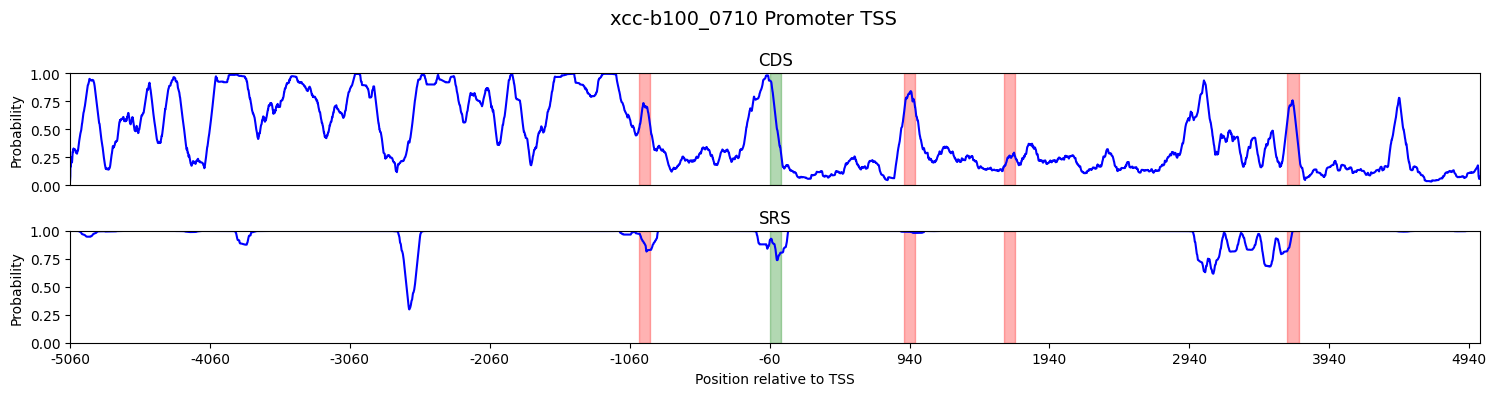

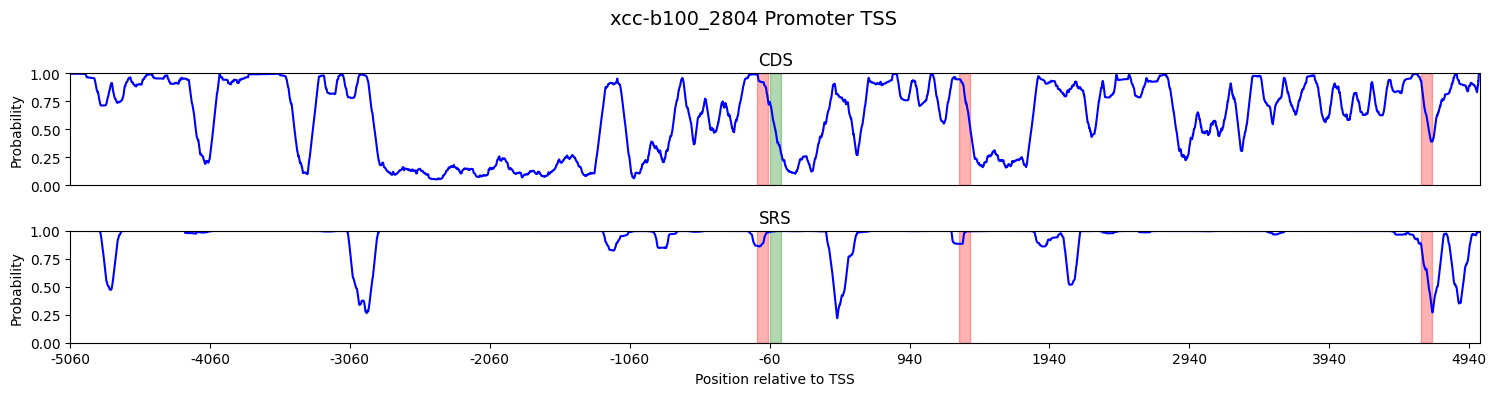

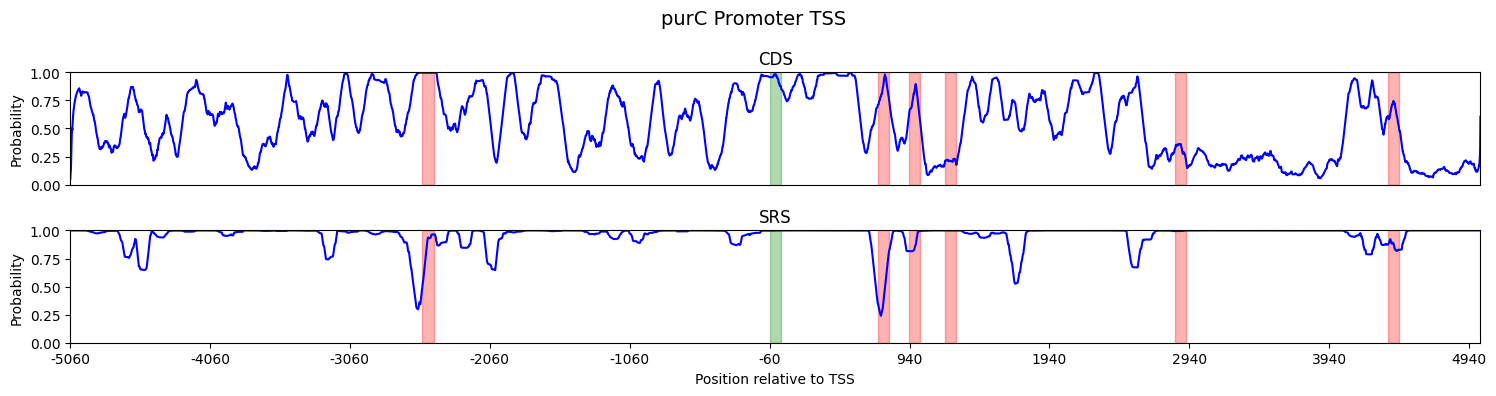

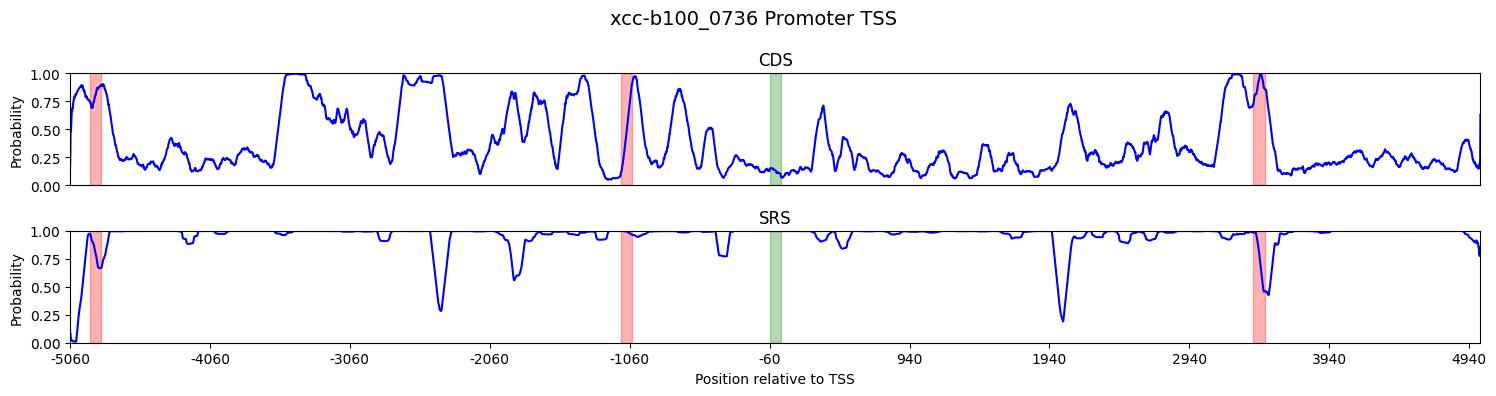

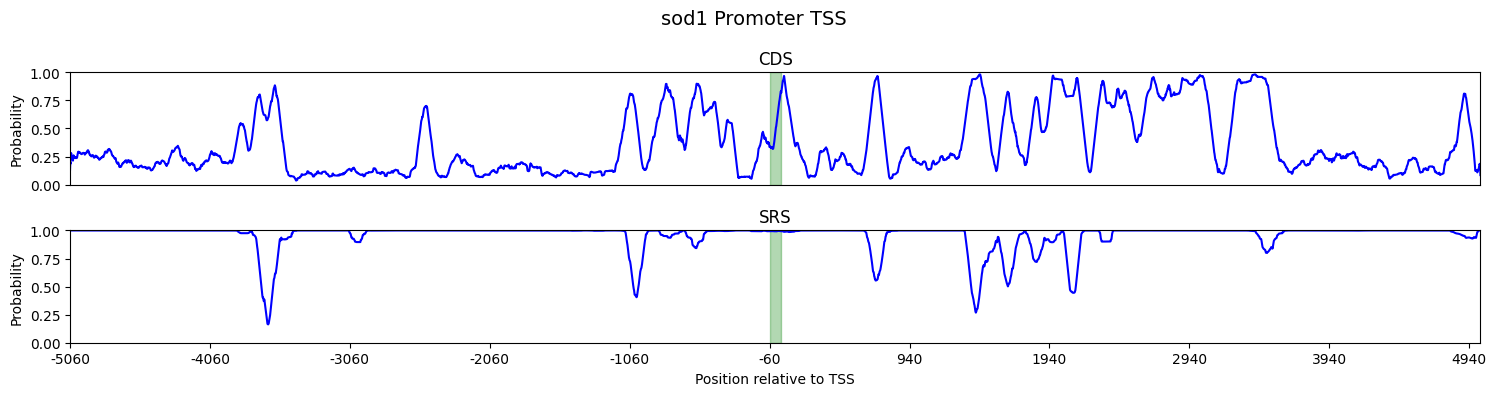

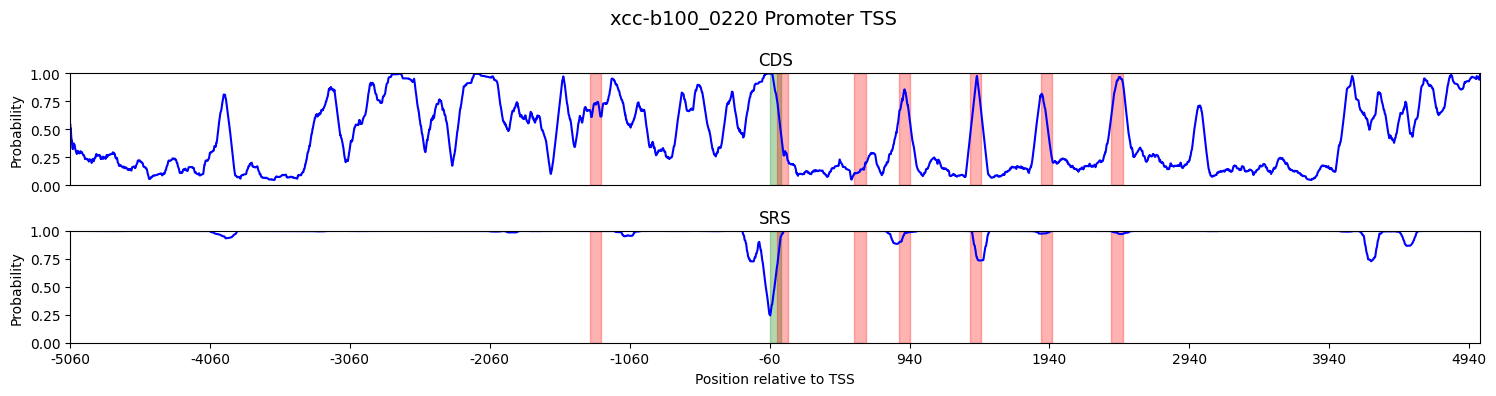

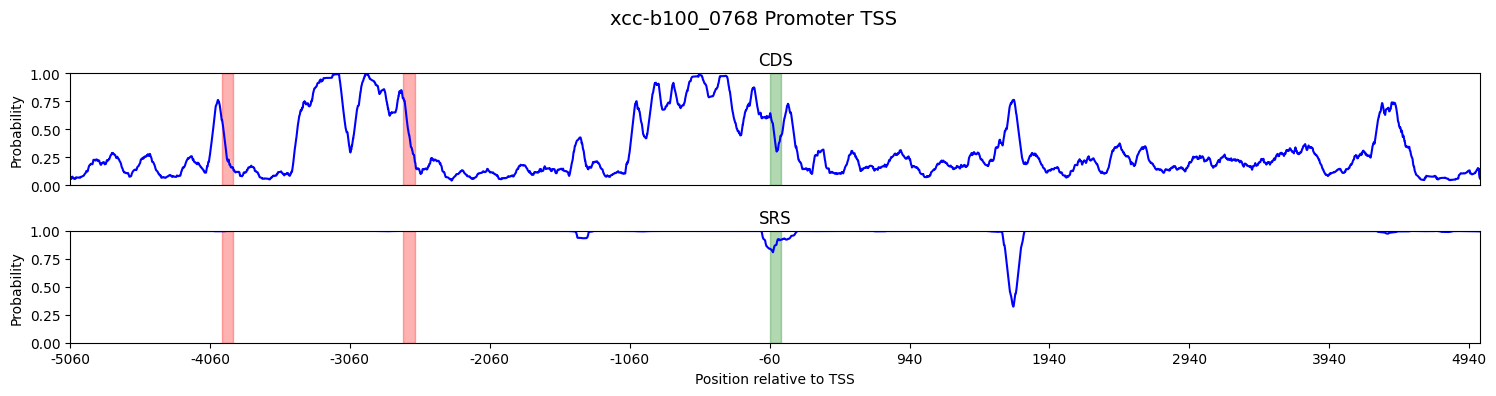

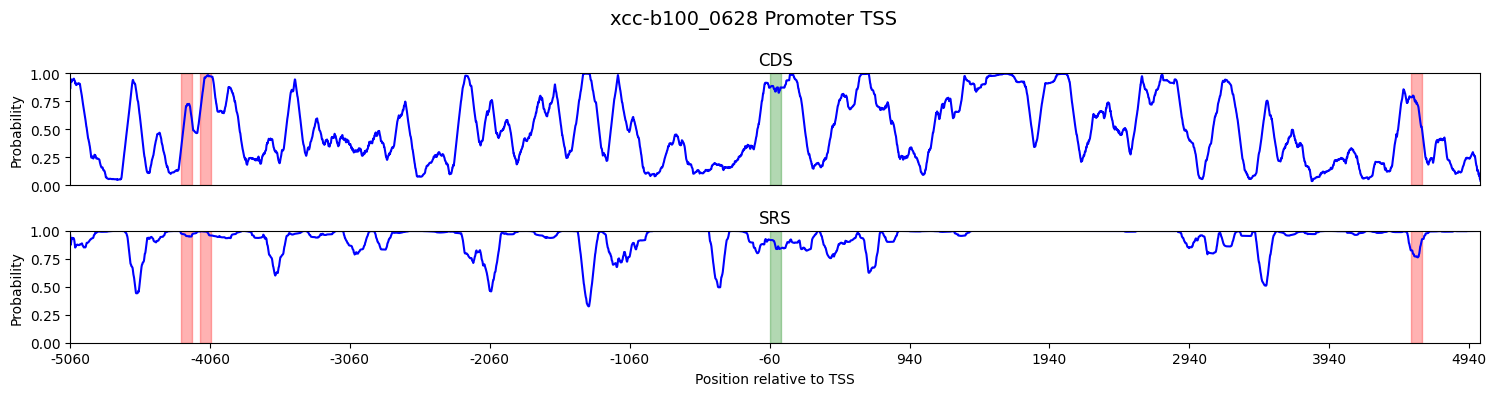

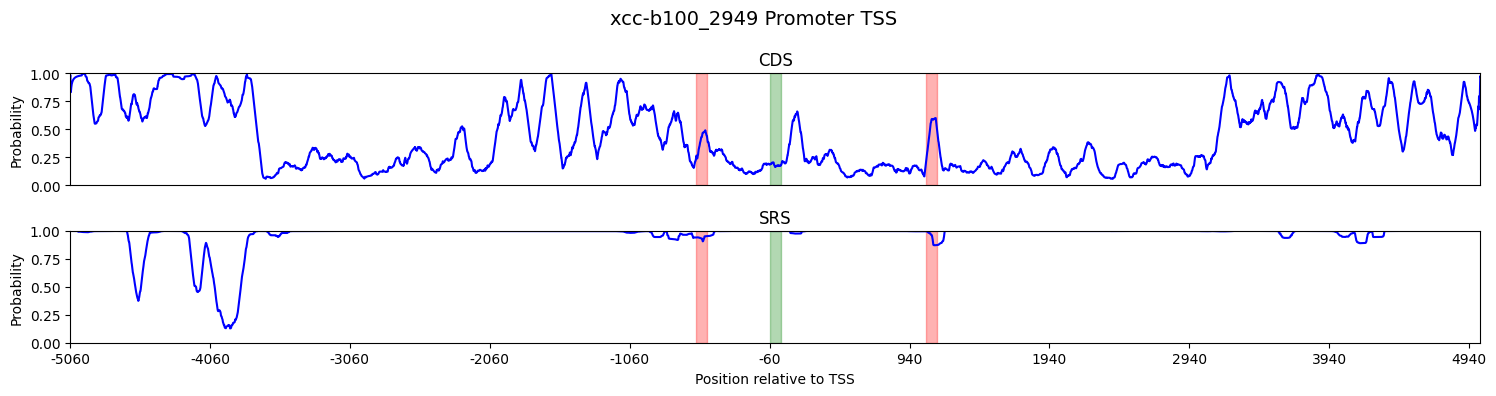

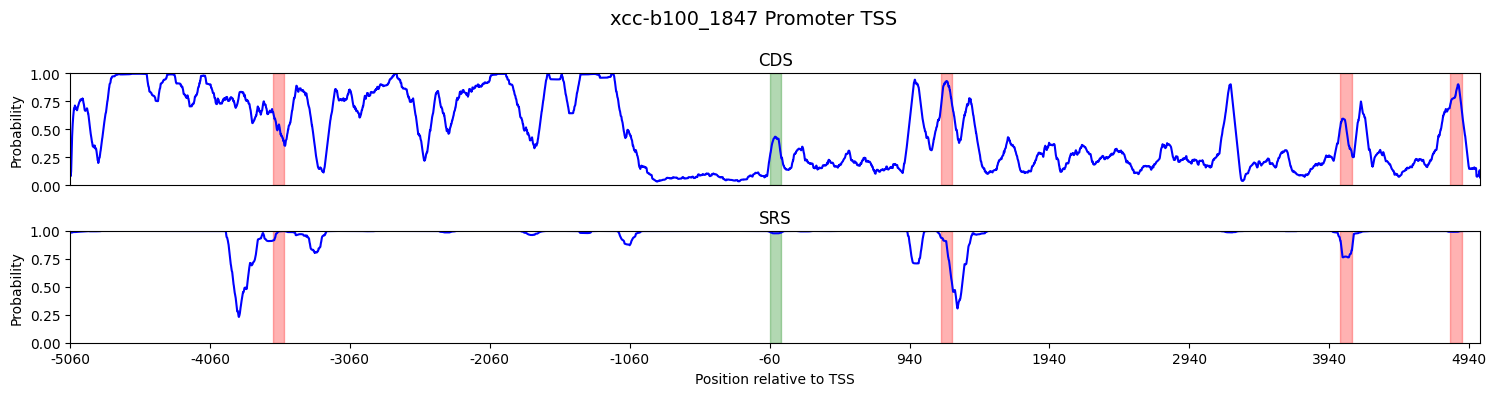

In [54]:
for index, promoter_tss in enumerate(sample_promoters_tss):
    title = f'{sample_promoters_label[index]} Promoter TSS'
    get_section_plot_merged(promoter_tss, genome_seq, model_cds, tokenizer_cds, model_random, tokenizer_random, 15, 4, title=title)